<a href="https://colab.research.google.com/github/JanhaviJaiswar26/NLP/blob/main/Speech_Disorder_F1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torchaudio
import torchaudio.transforms as transforms
import torch
import torch.nn.functional as F
import pandas as pd
import re
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, BertTokenizer, BertForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from google.colab import files

In [ ]:
# Upload audio file
uploaded = files.upload()
audio_file = list(uploaded.keys())[0]
print(f"Uploaded file: {audio_file}")

Saving 0126.wav to 0126 (1).wav
Uploaded file: 0126 (1).wav


In [ ]:
# Load Wav2Vec2 Model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model_asr = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Speech-to-Text Function (with Fixes)
def speech_to_text(audio_file):
    waveform, sample_rate = torchaudio.load(audio_file)

    # Convert Stereo to Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample to 16kHz
    if sample_rate != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
        waveform = resampler(waveform)

    # Ensure Correct Shape for Wav2Vec2
    waveform = waveform.squeeze(0)
    inputs = processor(waveform, sampling_rate=16000, return_tensors="pt")

    # Transcription
    with torch.no_grad():
        logits = model_asr(**inputs).logits
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(predicted_ids)[0]

    return transcription.lower().strip()

In [ ]:
# Load Dataset
df = pd.read_excel("/content/speech_disorder_dataset.xlsx")

In [ ]:
# Preprocess Text (Fixes)
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df["cleaned_text"] = df["text"].apply(clean_text)


In [ ]:
# NLP Classification: Random Forest
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)  # Improved TF-IDF
X = vectorizer.fit_transform(df["cleaned_text"])
y = df["label"]


In [ ]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X, y)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Predict Function for Random Forest
def predict_with_rf(text):
    text = clean_text(text)
    X_test = vectorizer.transform([text])
    return clf.predict(X_test)[0]

In [ ]:
# Run Full Pipeline
transcribed_text = speech_to_text(audio_file)
print(f"Transcribed Text: {transcribed_text}")

Transcribed Text: he ingressn himself ininkin what but oh


In [ ]:
# Predict Speech Disorder
predicted_disorder_rf = predict_with_rf(transcribed_text)


In [ ]:
print(f"Predicted Speech Disorder (Random Forest): {predicted_disorder_rf}")


Predicted Speech Disorder (Random Forest): stuttering


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Get model predictions
y_pred_rf = clf.predict(X)  # Predict using training data

# Evaluate Random Forest model
print("Random Forest Classification Report:")
print(classification_report(y, y_pred_rf))
print(f"Random Forest Accuracy: {accuracy_score(y, y_pred_rf):.4f}")

Random Forest Classification Report:
              precision    recall  f1-score   support

     apraxia       1.00      1.00      1.00        30
  dysarthria       1.00      1.00      1.00        30
      normal       1.00      1.00      1.00        30
  stuttering       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Random Forest Accuracy: 1.0000


In [ ]:
# NLP Classification: Fine-Tuned BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model_bert = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(df["label"].unique()))


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Predict Function for BERT
def classify_with_bert(text):
    text = clean_text(text)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model_bert(**inputs)
    probs = F.softmax(outputs.logits, dim=1)
    predicted_class = torch.argmax(probs).item()
    return df["label"].unique()[predicted_class]


In [ ]:
predicted_disorder_bert = classify_with_bert(transcribed_text)

In [ ]:
print(f"Predicted Speech Disorder (BERT): {predicted_disorder_bert}")

Predicted Speech Disorder (BERT): dysarthria


In [ ]:
import torch

def evaluate_bert():
    y_true = []
    y_pred = []

    for text, label in zip(df["text"], df["label"]):
        pred = classify_with_bert(text)  # Use the BERT function
        y_pred.append(pred)
        y_true.append(label)

    print("📊 BERT Classification Report:")
    print(classification_report(y_true, y_pred))
    print(f"✅ BERT Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# Run BERT evaluation
evaluate_bert()


📊 BERT Classification Report:
              precision    recall  f1-score   support

     apraxia       0.25      0.20      0.22        30
  dysarthria       0.27      0.87      0.41        30
      normal       0.00      0.00      0.00        30
  stuttering       0.00      0.00      0.00        30

    accuracy                           0.27       120
   macro avg       0.13      0.27      0.16       120
weighted avg       0.13      0.27      0.16       120

✅ BERT Accuracy: 0.2667


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt

# Assuming you have already computed the accuracy scores
accuracy_rf = accuracy_score(y, y_pred_rf)  # Random Forest Accuracy
accuracy_bert = accuracy_score(y_true, y_pred)  # BERT Accuracy

# Create a list of model names and their corresponding accuracies
models = ['Random Forest', 'BERT']
accuracies = [accuracy_rf, accuracy_bert]

# Plotting the accuracy graph
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylim([0, 1])  # Accuracy is between 0 and 1
plt.show()

NameError: name 'y_true' is not defined

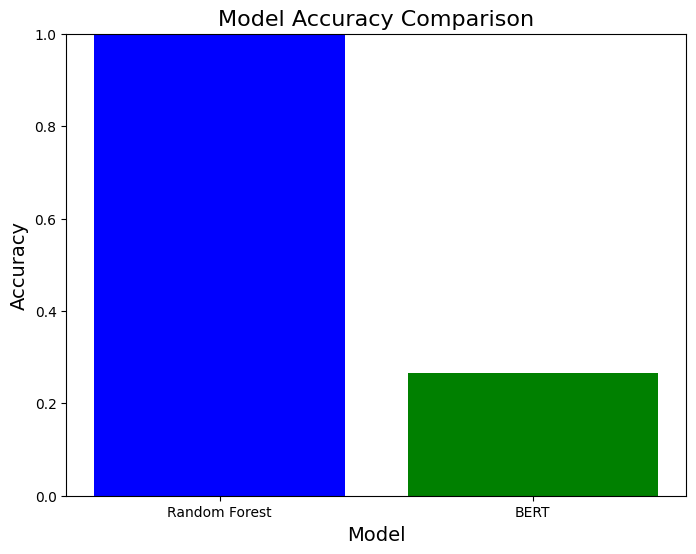

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming you have already computed the accuracy scores
accuracy_rf = accuracy_score(y, y_pred_rf)  # Random Forest Accuracy

# Call evaluate_bert to get y_true and y_pred
def evaluate_bert():
    y_true = []
    y_pred = []

    for text, label in zip(df["text"], df["label"]):
        pred = classify_with_bert(text)  # Use the BERT function
        y_pred.append(pred)
        y_true.append(label)

    return y_true, y_pred # Return y_true and y_pred

y_true, y_pred = evaluate_bert() # Call the function and assign values

accuracy_bert = accuracy_score(y_true, y_pred)  # BERT Accuracy

# Create a list of model names and their corresponding accuracies
models = ['Random Forest', 'BERT']
accuracies = [accuracy_rf, accuracy_bert]

# Plotting the accuracy graph
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylim([0, 1])  # Accuracy is between 0 and 1
plt.show()